# Practice 6.
##  Objectives:
1. Understand the decision trees for the case of classification.
2. See the effects of changing the parameters of the tree.

## Aplication:
Data base: Datasets for "The Elements of Statistical Learning"
(https://web.stanford.edu/~hastie/ElemStatLearn/data.html)

 Database: coronary heart disease (CHD), https://web.stanford.edu/~hastie/ElemStatLearn/datasets/SAheart.data
- Predict **CHD** (1 or  0)


In [1]:
import pandas as pd
import os 
import matplotlib.pyplot as plt
import numpy as np
from sklearn import tree
from sklearn.tree import export_text
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV



In [2]:
File = "SouthAfricanHeartDesease.csv"
Filename = os.path.join(os.getcwd(),'Data',File)
print(f'Filename with path: \n {Filename}')
Data = pd.read_csv(Filename)
Data.head().T

Filename with path: 
 c:\mlearn-lab\SixthPractice\Data\SouthAfricanHeartDesease.csv


,0,1,2,3,4
row.names,1,2,3,4,5
sbp,160,144,118,170,134
tobacco,12.0,0.01,0.08,7.5,13.6
ldl,5.73,4.41,3.48,6.41,3.5
adiposity,23.11,28.61,32.28,38.03,27.78
famhist,Present,Absent,Present,Present,Present
typea,49,55,52,51,60
obesity,25.3,28.87,29.14,31.99,25.99
alcohol,97.2,2.06,3.81,24.26,57.34
age,52,63,46,58,49


## Clean the database
###  Check there is no problem

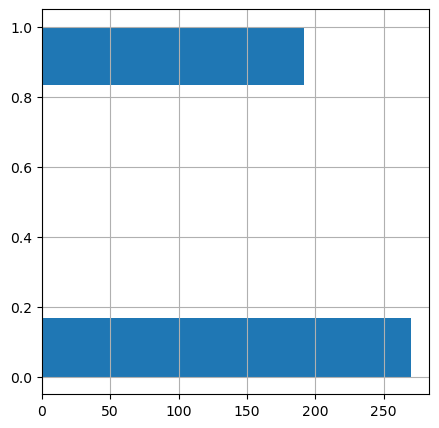

In [3]:
Coding_famhist ={'Present':1,'Absent':0}
Data['famhist'] = Data['famhist'].map(Coding_famhist)
ax =Data['famhist'].hist(figsize= (5,5),orientation="horizontal",bins = 6)

Data.drop(columns = ['row.names'],inplace = True)

### Let us see if the data is balanced

Note: predicted qualities are almost balanced 


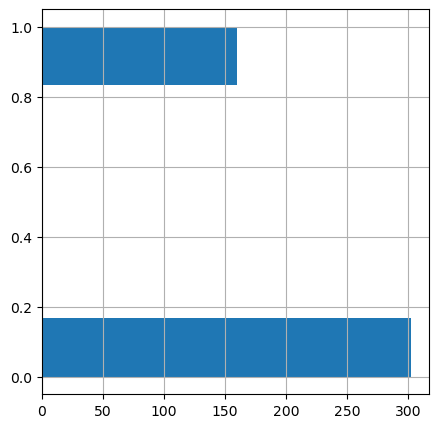

In [4]:
ax =Data['chd'].hist(figsize= (5,5),orientation="horizontal",bins = 6)
print('Note: predicted qualities are almost balanced ')

##  Let us see the histograms

###  Features that would give problems in a Linear Classifier, PCA, LDA, and others

1- **Different units** between features. Note that Decision Trees are robust to this feature, while in other ML techniques you should consider standarize (see practice 5)

2- Some features are not **Gaussian**

3- Some features have high **Standard Deviation**  (this is a problem for algorithms based on correlations)

4- Note that tobaco and alcohol have the median (percentile 50%) quite different from the mean. Also in these cases the standard deviation is bigger than the mean. In the future we will deal with features with these properties.

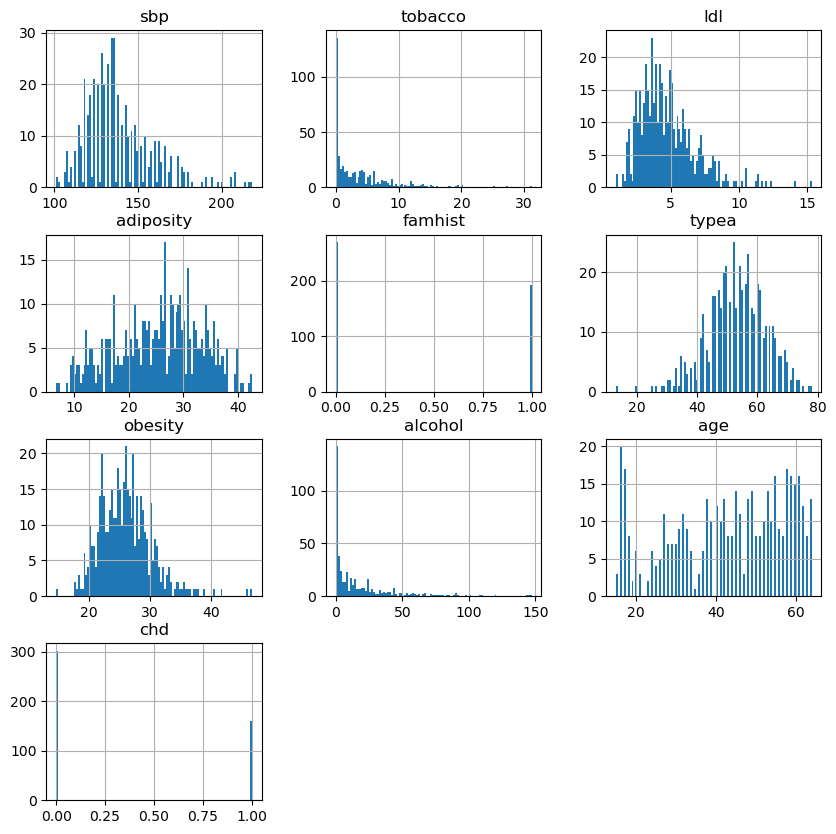

In [5]:
ax =Data.hist(figsize= (10,10),bins = 100)

### Excercise: <font color='red'> If we were working with a linear regression method, suggest a transformation for the variables tabaco and alcohol that might improve the working of the linear regression.</font>
**Spoiler:**  In decision trees it is not necessary. Explain why?

In [6]:
Data.describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
sbp,462.0,138.33,20.50,101.00,124.00,134.00,148.00,218.00
tobacco,462.0,3.64,4.59,0.00,0.05,2.00,5.50,31.20
ldl,462.0,4.74,2.07,0.98,3.28,4.34,5.79,15.33
adiposity,462.0,25.41,7.78,6.74,19.77,26.12,31.23,42.49
famhist,462.0,0.42,0.49,0.00,0.00,0.00,1.00,1.00
typea,462.0,53.10,9.82,13.00,47.00,53.00,60.00,78.00
obesity,462.0,26.04,4.21,14.70,22.98,25.80,28.50,46.58
alcohol,462.0,17.04,24.48,0.00,0.51,7.51,23.89,147.19
age,462.0,42.82,14.61,15.00,31.00,45.00,55.00,64.00
chd,462.0,0.35,0.48,0.00,0.00,0.00,1.00,1.00


## Let us look into the scatter plot matrix to see if there is a regularity in the data

In [7]:
if False:
    ax = pd.plotting.scatter_matrix(Data,c =Data['chd'], figsize = (10,10))

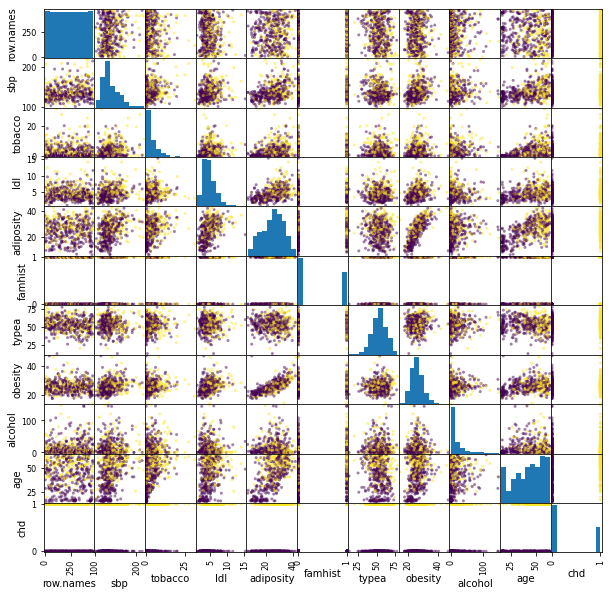

### Excercise: <font color='red'> Note that adiposity and obesity input variables are correlated .</font>
1. Explain *briefly*, why this is bad in the case of linear regression (or similar procedures).
2. Explain *briefly*, why in decision trees this is not so important.

## Let us train a classifier

##  First we partition database into train and test
### Note the helper function

In [8]:
def PartitionOfDatabase(Data,Fraction = 0.75):
    NumSamples, NumFeatures = Data.shape
    Index = list(range(NumSamples))
    RandomIndex = np.random.permutation(Index)
    NumTrainElements = int(Fraction*NumSamples)
    TrainIndex = RandomIndex[:NumTrainElements]
    TestIndex = RandomIndex[NumTrainElements:]
    TrainDB = Data.iloc[TrainIndex]
    TestDB = Data.iloc[TestIndex]
    return TrainDB,TestDB
TrainDB,TestDB = PartitionOfDatabase(Data,Fraction = 0.75)

In [9]:
y = TrainDB['chd']
InputFeatures = [fea for fea in TrainDB.columns if  fea != 'chd']
print(f' Input variables: \n {InputFeatures}')
print('_'*50)
X = TrainDB[InputFeatures]

 Input variables: 
 ['sbp', 'tobacco', 'ldl', 'adiposity', 'famhist', 'typea', 'obesity', 'alcohol', 'age']
__________________________________________________


### We create the decision tree object and fit the model to the Training database.

In [10]:
clf = tree.DecisionTreeClassifier()
clf = clf.fit(X, y)

##  We print the decision rules that explain how the **diagnosis** is **explained** by the data.

1. ###  Note the hierarchy of variables. 
1. ###  Note the depth of the tree.

<font color='blue'> **Concept:** Works like a look up table. </font>

In [11]:
r = export_text(clf, feature_names=InputFeatures)
print(r)

|--- age <= 49.50
|   |--- tobacco <= 0.51
|   |   |--- obesity <= 18.48
|   |   |   |--- sbp <= 116.00
|   |   |   |   |--- class: 0
|   |   |   |--- sbp >  116.00
|   |   |   |   |--- class: 1
|   |   |--- obesity >  18.48
|   |   |   |--- age <= 39.50
|   |   |   |   |--- typea <= 66.50
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- typea >  66.50
|   |   |   |   |   |--- sbp <= 126.00
|   |   |   |   |   |   |--- age <= 25.00
|   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |--- age >  25.00
|   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |--- sbp >  126.00
|   |   |   |   |   |   |--- class: 0
|   |   |   |--- age >  39.50
|   |   |   |   |--- alcohol <= 6.35
|   |   |   |   |   |--- age <= 44.00
|   |   |   |   |   |   |--- sbp <= 143.00
|   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |--- sbp >  143.00
|   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- age >  44.00
|   |   |   |   |   |   |--- class: 0
|   

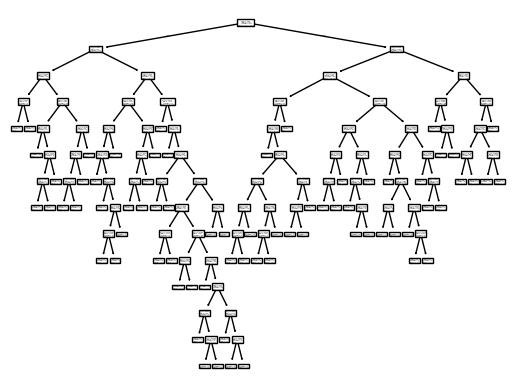

In [12]:
tree.plot_tree(clf)
plt.show()

### Excercise: <font color='red'> Provide a short common sense explanation of why a tree that works like a **look up table** is a bad solution .</font>

### Next we look at the details of the higher levels.

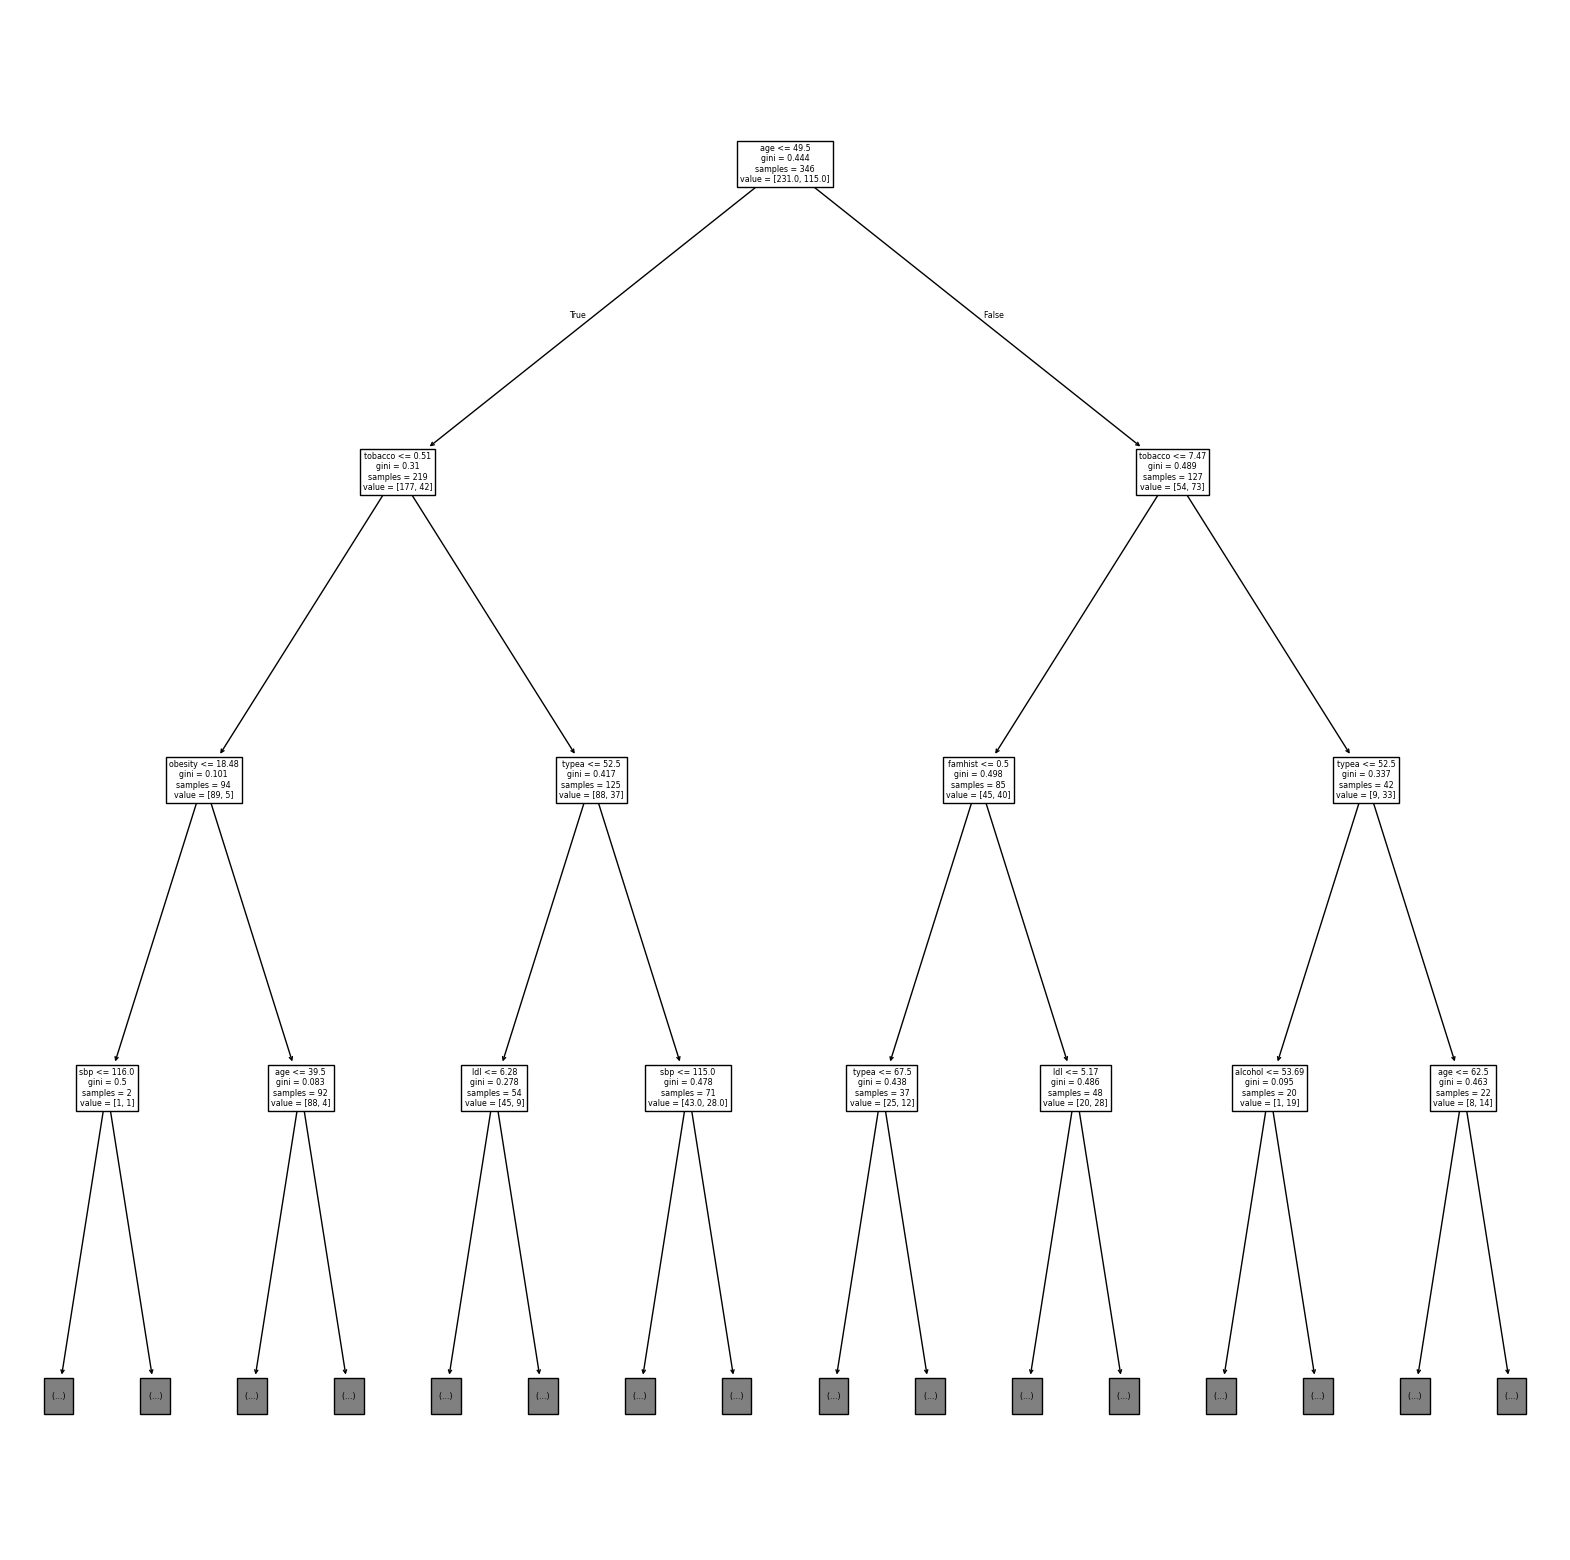

In [13]:
plt.figure(figsize=(20,20))
ax = tree.plot_tree(clf,max_depth = 3,feature_names = InputFeatures,impurity = True)
plt.show()

### Homework: <font color='red'>  Try to see if there is a similarity between the information given by the scatter plot and the hierarchy of variables. Note that a set of questions along one branch can be seen as a kind of correlation</font>

<font color='red'>  See the Gini Coefficients, they are are near 1/2 in the higher nodes but disminishes in the lower ones. Why?  Note the variable **Value**, is giving the number of elements of each class</font>

## Let us control the training of the tree

1. min_samples_split: We want to control the number in order to have significative statistics.

2. max_depth: depth we allow for the tree. Will stop growth.

3. min_samples_leaf: We want to have enoughs examples per decision.

4. class_weight:  Allows to control balance between *True Positives* and *False Negatives*.

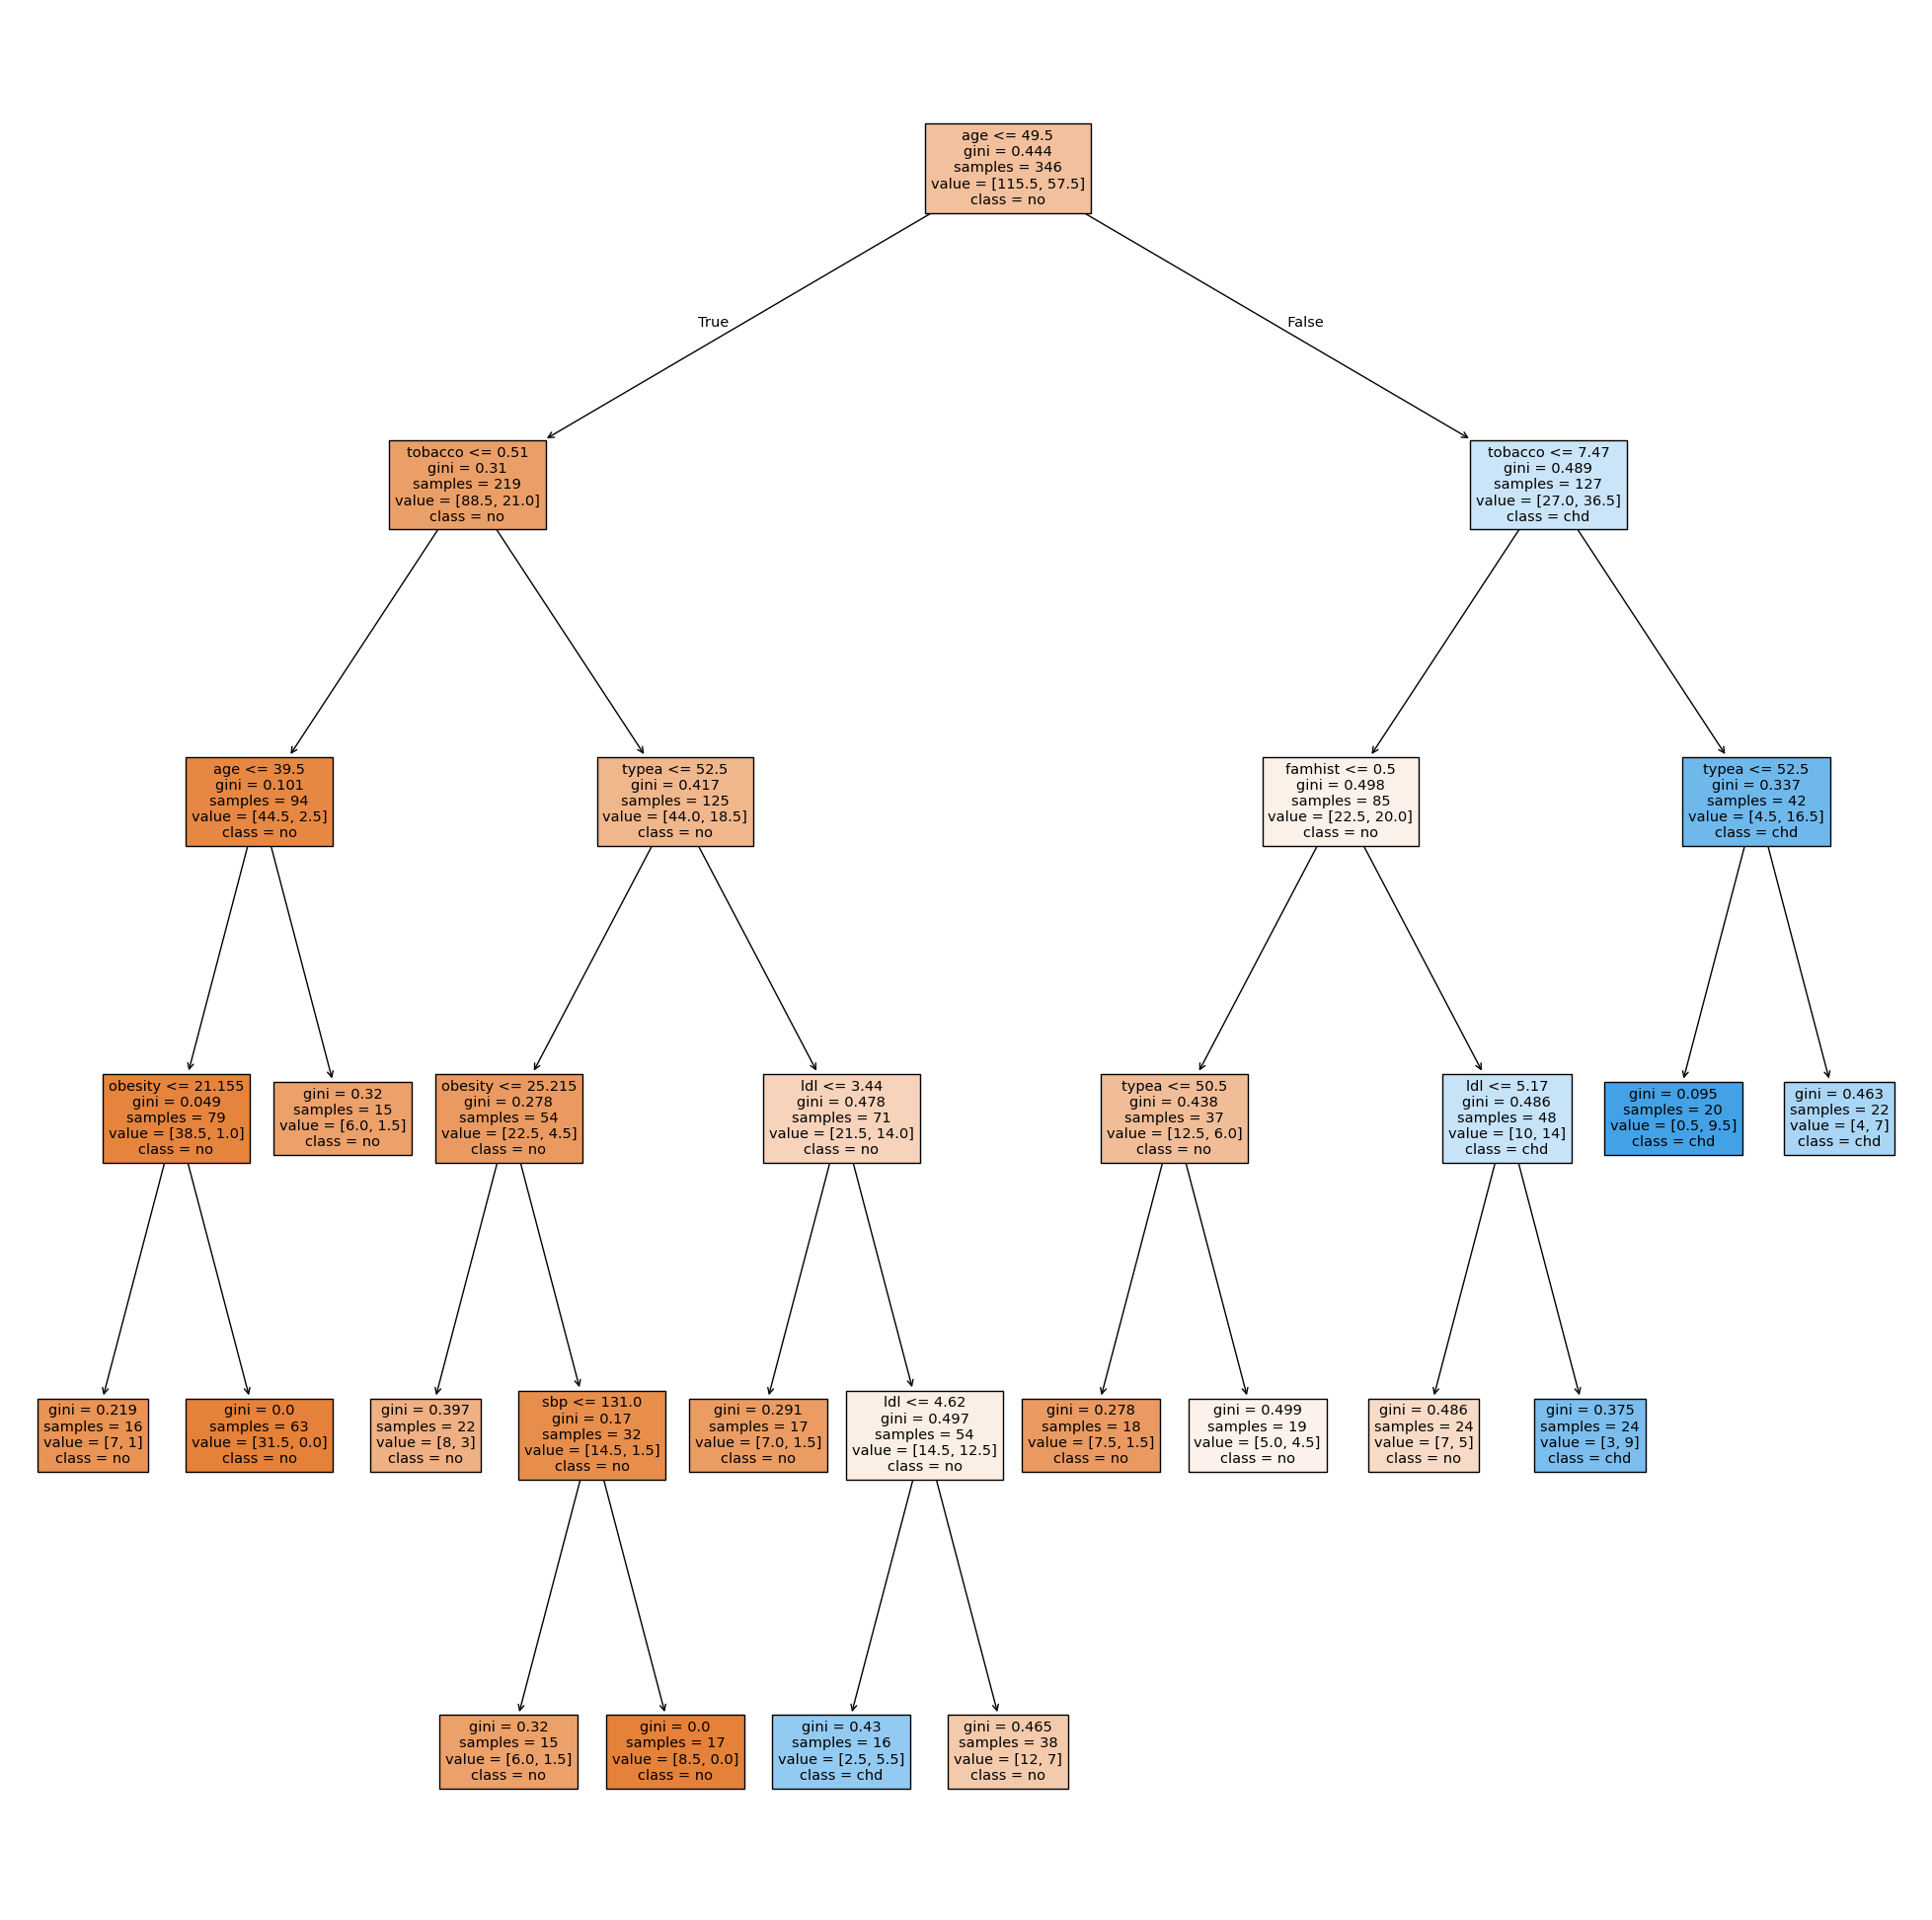

In [14]:
clf = tree.DecisionTreeClassifier(min_samples_split = 10,max_depth =5,min_samples_leaf =15,class_weight = {0:0.5,1:0.5})
clf = clf.fit(X, y)
plt.figure(figsize=(25,25))
ax = tree.plot_tree(clf,feature_names = InputFeatures,impurity = True,class_names =['no','chd'],filled = True)
plt.show()

## Behaviour on test database
### Performance index: Accuracy score

**Definition:**
$\texttt{accuracy}(y, \hat{y}) = \frac{1}{n_\text{samples}} \sum_{i=0}^{n_\text{samples}-1} 1(\hat{y}_i = y_i)$

**Note:** There are more performance indices. We will see them further in the course.

##  Performance on train

Accuracy (train)  78.9% 
[[211  20]
 [ 53  62]]


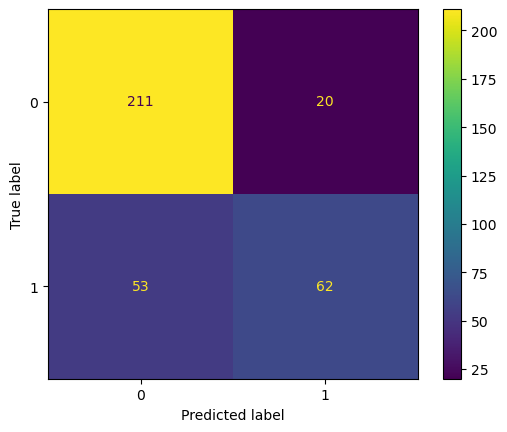

In [15]:
y_hat = clf.predict(X)
accuracy = accuracy_score(y, y_hat)
print("Accuracy (train)  %0.1f%% " % ( accuracy * 100))
print(confusion_matrix(y, y_hat))
ConfusionMatrixDisplay.from_estimator(clf, X, y)  
plt.show()

## Performance on test

Accuracy (test)  67.2% 
Predicted Label   0   1
True Label             
0                59  12
1                26  19


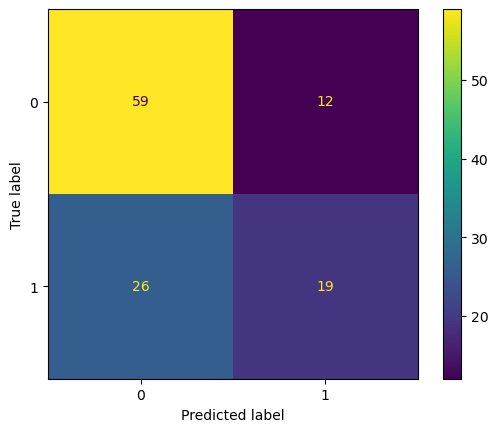

In [16]:
y_tst = TestDB['chd']
X_tst = TestDB[InputFeatures]
y_hat_tst = clf.predict(X_tst)
accuracy = accuracy_score(y_tst, y_hat_tst)
print("Accuracy (test)  %0.1f%% " % ( accuracy * 100))

# Pretty print the confusion matrix with labels
labels = sorted(list(set(y_tst)))

cm = confusion_matrix(y_tst, y_hat_tst)
df_cm = pd.DataFrame(cm, index=labels, columns=labels)
df_cm.index.name = 'True Label'
df_cm.columns.name = 'Predicted Label'

print(df_cm)

ConfusionMatrixDisplay.from_estimator(clf, X_tst, y_tst)  
plt.show()

## Cross-validation to find the optimal parameters


1. min_samples_split: We want to control the number in order to have significative statistics.

2. max_depth: depth we allow for the tree. Will stop growth.

3. min_samples_leaf: We want to have enoughs examples per decision.

4. class_weight:  Allows to control balance between *True Positives* and *False Negatives*.

In [17]:



# 1. Prepare the training data as requested
X_train = TrainDB[InputFeatures]
y_train = TrainDB['chd']

# 2. Define the parameter grid for the Decision Tree
param_grid = {
    'min_samples_split': [2, 10, 20, 50],
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_leaf': [1, 5, 10, 20],
    'class_weight': [None, 'balanced', {0: 1, 1: 2}]
}

# 3. Initialize and run GridSearchCV
dt_classifier = DecisionTreeClassifier(random_state=42)
grid_search = GridSearchCV(
    estimator=dt_classifier, 
    param_grid=param_grid, 
    cv=5, 
    scoring='accuracy', 
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

# 4. Use the best model to predict (assuming X_tst and y_tst are available)
best_model = grid_search.best_estimator_
y_hat_tst = best_model.predict(X_tst)

# 5. Display the Confusion Matrix with the requested labels
cm = confusion_matrix(y_tst, y_hat_tst)
df_cm = pd.DataFrame(cm)
df_cm.index.name = 'True Label'
df_cm.columns.name = 'Predicted Label'

print("Best Parameters:", grid_search.best_params_)
print("\nConfusion Matrix:")
print(df_cm)


# 5. Extract results
print(f"Best Parameters: {grid_search.best_params_}")
print("Accuracy (cross validation): %0.1f%%" % (grid_search.best_score_ * 100))
# You can now use the best estimator for your final predictions
best_model = grid_search.best_estimator_
y_hat_tst = best_model.predict(X_tst)


Best Parameters: {'class_weight': None, 'max_depth': None, 'min_samples_leaf': 20, 'min_samples_split': 50}

Confusion Matrix:
Predicted Label   0   1
True Label             
0                62   9
1                24  21
Best Parameters: {'class_weight': None, 'max_depth': None, 'min_samples_leaf': 20, 'min_samples_split': 50}
Accuracy (cross validation): 70.5%


### Homework: <font color='red'>  Compare briefly with the results above in train and test.</font>

#### <font color='red'> For a job interview </font>
Why the number 42 ? (random_state=42)

**Ask google**: what is the number 42?

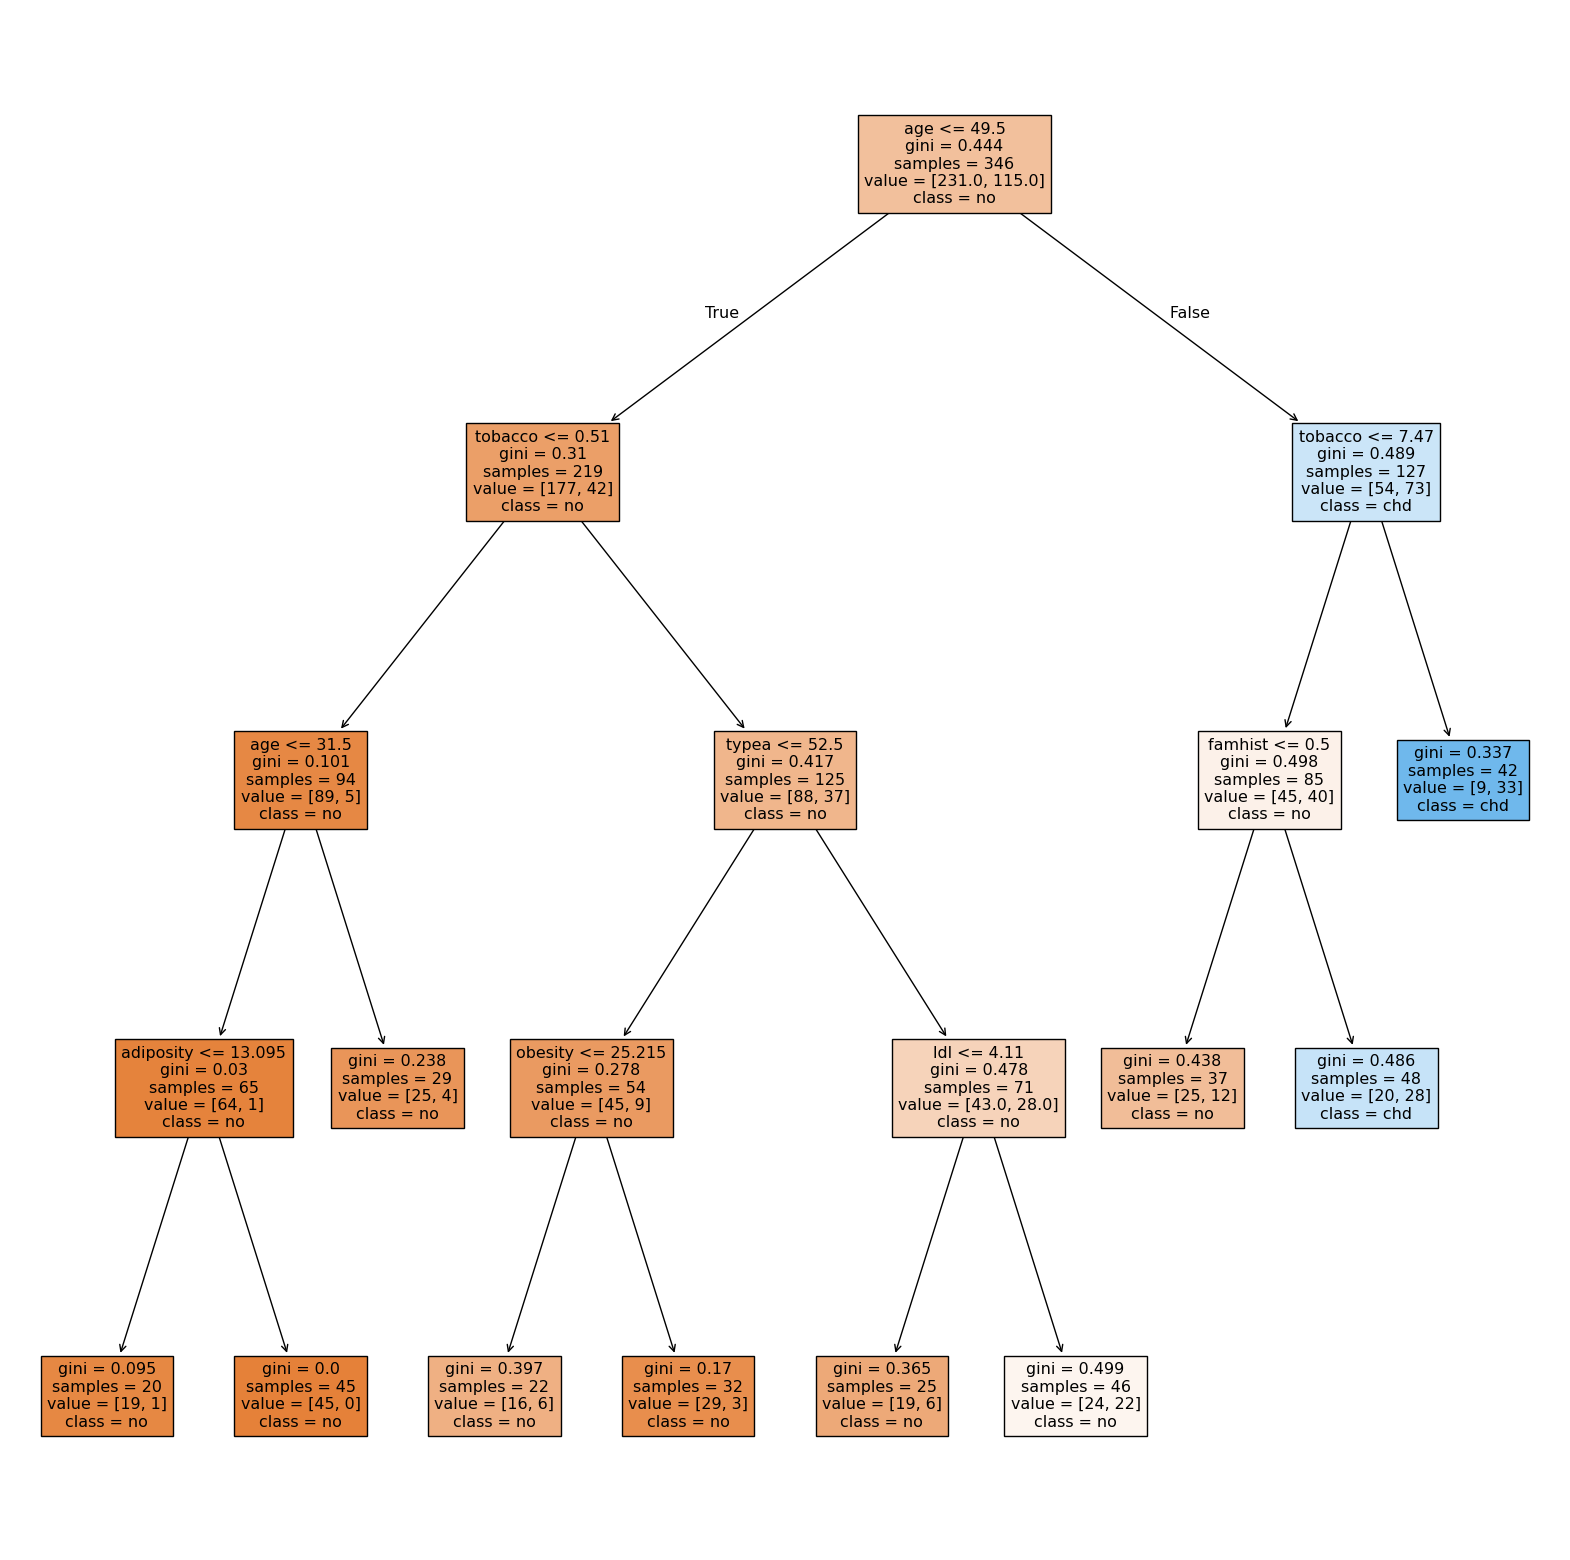

In [18]:
plt.figure(figsize=(20,20))
ax = tree.plot_tree(best_model,feature_names = InputFeatures,impurity = True,class_names =['no','chd'],filled = True)
plt.show()

### Homework: <font color='red'>   Compute the performance after standarizing the data, so that it has mean zero and standard deviation equal to one. </font>
I.e. $z = {(x - mean) \over  std}$  (see practice 5 for an example)
### Homework: <font color='red'>    Explain the result.</font>

### Homework: <font color='red'>    Compute the new tree setting alcohol and tobaco in logarithmic scale. This should improve quite a lot the performance in the case of linear classifiers, etc. What happens with the decision tree? </font>
### Homework: <font color='red'>    Explain the result.</font>

### Excercise: <font color='red'> Create an executive report </font>
Write a short assessment of the work done. Difficulties, challenges, and proposals for a solution.


 ### Excercise: <font color='red'> Create an infographic for the work done </font>
 Use either notebooklm or any chat.
 Refine the prompt so that the explanation of the work done is clear.


## Description of variables: coronary heart disease (CHD)

A retrospective sample of males in a heart-disease high-risk region
of the Western Cape, South Africa. There are roughly two controls per
case of CHD. Many of the CHD positive men have undergone blood
pressure reduction treatment and other programs to reduce their risk
factors after their CHD event. In some cases the measurements were
made after these treatments. These data are taken from a larger
dataset, described in  Rousseauw et al, 1983, South African Medical
Journal. 
### Input variables:

* sbp systolic blood pressure
* tobacco cumulative tobacco (kg)
* ldl low densiity lipoprotein cholesterol
* adiposity
* famhist family history of heart disease (Present, Absent)
* typea type-A behavior
* obesity
* alcohol current alcohol consumption
* age age at onset
* chd response, coronary heart disease